# Stochastic Gradient Descent vs. Adam Estimation Momentum

**Imports**

In [22]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torch import nn


**Datensetz laden und einheitliche Bildtransformtion**

In [23]:
transformation_pipeline = v2.Compose([
    v2.Resize((64, 64)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), #Bringt alle Bilder auf eine ähnliche Farbskala (Werte nach ImageNet standard gewählt)
])

weather_dataset = datasets.ImageFolder(root=r'C:\Users\demyi\Desktop\UNI\KI\KIP\KIPraktikum\3. Termin\weather_data', transform=transformation_pipeline)

**Datensatz in trainings, validierungs und test Submengen aufteilen und Präperation von batches für das neuronale Netz**

In [24]:
train_weather_dataset, validate_weather_dataset, test_weather_dataset = torch.utils.data.random_split(weather_dataset, [0.7, 0.15, 0.15])

train_weather_dataloader = DataLoader(train_weather_dataset, batch_size=32, shuffle=True)
validate_weather_dataloader = DataLoader(validate_weather_dataset, batch_size=32, shuffle=False)
test_weather_dataloader = DataLoader(test_weather_dataset, batch_size=32, shuffle=False)

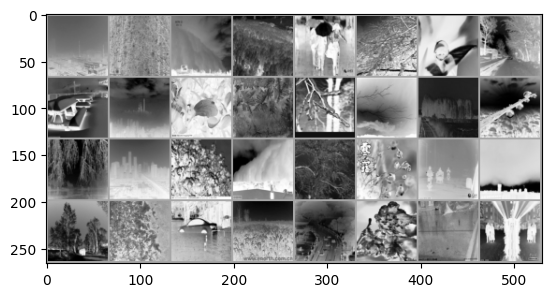

In [25]:
# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(train_weather_dataloader)
images, labels = next(dataiter)

img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)

# Neuronales Netz bauen (3 Farbkanäle (RGB))

In [26]:
input_size = 3 * 64 * 64
hidden_size = 256
output_size = 11



class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = nn.functional.sigmoid(self.fc1(x))
        x = self.fc2(x)
        return x


model = NeuralNetwork()
model_sgd = NeuralNetwork()
model_adam = NeuralNetwork()

print(model)
total_params = sum(p.numel() for p in model.parameters())
weights_count = sum(p.numel() for n, p in model.named_parameters() if 'weight' in n)
biases_count = sum(p.numel() for n, p in model.named_parameters() if 'bias' in n)
print(f"Total parameters: {total_params:,}")
print(f"Total Weight Elements: {weights_count:,}")
print(f"Total Bias Elements: {biases_count:,}")

loss_fn = nn.CrossEntropyLoss()

NeuralNetwork(
  (fc1): Linear(in_features=12288, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=11, bias=True)
)
Total parameters: 3,148,811
Total Weight Elements: 3,148,544
Total Bias Elements: 267


In [ ]:
training_loss_sgd = []
training_loss_adam = []
validate_loss_sgd = []
validate_loss_adam = []

epochs = 15
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.01)

for epoch in range(epochs):
    model_sgd.train()
    model_adam.train()

    epoch_train_loss_sgd = 0.0
    epoch_train_loss_adam = 0.0

    for x, y in train_weather_dataloader:
        #sgd
        optimizer_sgd.zero_grad()
        output_sgd = model_sgd(x) #Bilder übergeben
        loss_sgd = loss_fn(output_sgd, y)
        loss_sgd.backward()
        optimizer_sgd.step()
        epoch_train_loss_sgd += loss_sgd.item()

        #adam
        optimizer_adam.zero_grad()
        output_adam = model_adam(x)
        loss_adam = loss_fn(output_adam, y)
        loss_adam.backward()
        optimizer_adam.step()
        epoch_train_loss_adam += loss_adam.item()
    
    training_loss_sgd.append(epoch_train_loss_sgd / len(train_weather_dataloader))
    training_loss_adam.append(epoch_train_loss_adam / len(train_weather_dataloader))

    model_sgd.eval()
    model_adam.eval()

    epoch_val_loss_sgd = 0.0
    epoch_val_loss_adam = 0.0
    
    # torch.no_grad() deaktiviert die Gradientenberechnung (spart massiv Speicher & Zeit)
    with torch.no_grad():
        for x, y in validate_weather_dataloader:
            # SGD Validierung
            output_sgd = model_sgd(x)
            loss_sgd = loss_fn(output_sgd, y)
            epoch_val_loss_sgd += loss_sgd.item()
            
            # Adam Validierung
            output_adam = model_adam(x)
            loss_adam = loss_fn(output_adam, y)
            epoch_val_loss_adam += loss_adam.item()
    
    validate_loss_sgd.append(epoch_val_loss_sgd / len(validate_weather_dataloader))
    validate_loss_adam.append(epoch_val_loss_sgd / len(validate_weather_dataloader))

print("Training finished")


Training finished
Training finished
Training finished
Training finished
Training finished
Training finished
Training finished
Training finished
Training finished
Training finished
Training finished
Training finished
Training finished
Training finished
Training finished


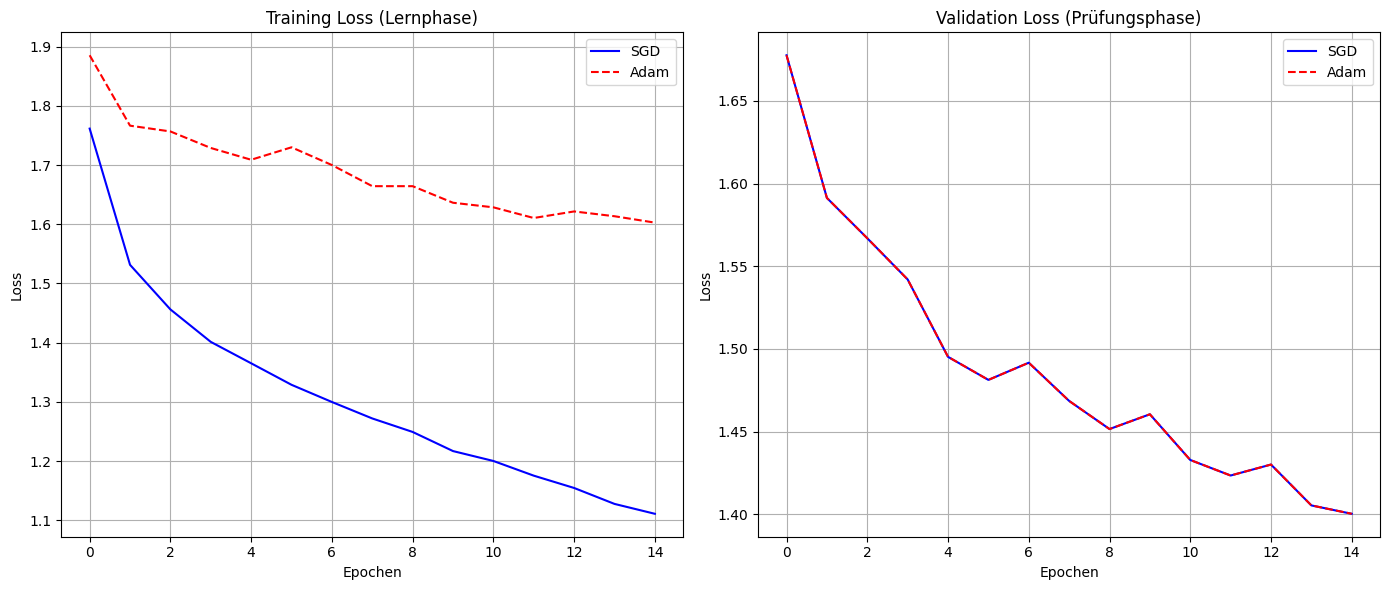

In [28]:
plt.figure(figsize=(14, 6))

# Subplot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(training_loss_sgd, label='SGD', color='blue')
plt.plot(training_loss_adam, label='Adam', color='red', linestyle='--')
plt.title('Training Loss (Lernphase)')
plt.xlabel('Epochen')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Validation Loss
plt.subplot(1, 2, 2)
plt.plot(validate_loss_sgd, label='SGD', color='blue')
plt.plot(validate_loss_adam, label='Adam', color='red', linestyle='--')
plt.title('Validation Loss (Prüfungsphase)')
plt.xlabel('Epochen')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()